# 3.3.3 DIEN 兴趣演化排序

> 阅读版与 Web 应用内容一致；实验数值来自本 Notebook 的已执行输出。

## Goal

当兴趣从旧主题转向新主题时，怎样区分“出现过什么”和“现在更想要什么”？

## Setup

默认 `smoke` 档使用仓库内固定版本的 GroupLens **MovieLens latest-small** 真实行为子集，CPU 可重复执行；`full` 档只扩大真实数据规模与训练配置，不切换到合成数据。数据包含真实匿名用户、电影、评分和时间戳；实验只做确定性截取与任务重构，不随机制造交互、标签或行为序列。原始许可与引用保存在 `data/ml-latest-small/README.txt`。

**主要资料：** [Zhou et al., 2019, DIEN](https://arxiv.org/abs/1809.03672)

In [1]:
from pathlib import Path
import os, sys, json
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
os.environ.setdefault("RECSYS_PROFILE", "smoke")
PROFILE = os.environ["RECSYS_PROFILE"]
from recsys_lab.data import load_movielens, movielens_provenance
real_ratings, real_movies = load_movielens()
REAL_DATASET = movielens_provenance(real_ratings)
print({"profile": PROFILE, "root": str(ROOT), "real_dataset": REAL_DATASET})
assert REAL_DATASET["randomly_fabricated_rows"] == 0

/usr/local/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


{'profile': 'smoke', 'root': '/workspace', 'real_dataset': {'dataset': 'MovieLens latest-small (GroupLens, generated 2018-09-26)', 'source': 'https://files.grouplens.org/datasets/movielens/ml-latest-small.zip', 'license_file': '/workspace/data/ml-latest-small/README.txt', 'rows_used': 26732, 'users_used': 120, 'items_used': 600, 'time_min_utc': '1996-10-17T11:51:49+00:00', 'time_max_utc': '2018-09-13T21:38:16+00:00', 'positive_rule': 'like := observed rating >= 4.0; very_like := observed rating >= 4.5', 'randomly_fabricated_rows': 0}}


## 学习地图

1. 从原始论文理解系统约束；
2. 用可手算数字读懂公式和形状；
3. 检查数据、切分与标签；
4. 使用工业框架模型类训练；
5. 分开验证训练、推理和测试；
6. 用实际输出讨论失败边界。

**本节问题：** 当兴趣从旧主题转向新主题时，怎样区分“出现过什么”和“现在更想要什么”？

**先修知识：** 3.0 的向量、概率与损失函数。第一次阅读无需推导梯度，只要能解释输入、输出和形状。

## Paper & Context

DIEN 用 GRU 抽取逐时刻兴趣状态，以辅助下一行为损失提供额外监督，再用目标感知 AUGRU 控制状态演化。它比 DIN 更重，收益依赖严格时间顺序和高质量负序列。

**来源：** [Zhou et al., 2019, DIEN](https://arxiv.org/abs/1809.03672)

请区分三层证据：论文中的离线实验、本 Notebook 验证的代码链路、生产系统尚需验证的在线收益。三者不能互相替代。

## Math by Hand

GRU 是带记忆的递推函数 $h_t=\mathrm{GRU}(e_t,h_{t-1})$。辅助损失要求 $h_t$ 更像下一次真实行为、远离负样本。AUGRU 用候选相关权重控制每步写入多少。因此两个相同集合的不同排列会得到不同末状态。

下面用 NumPy/Matplotlib 验证直觉。二维图只是教学投影，工业 embedding 虽有更多维，计算规则相同。

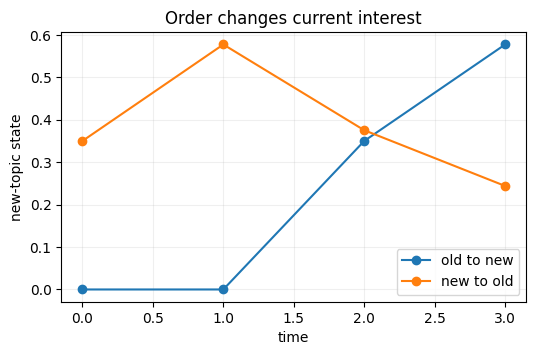

In [2]:
import numpy as np, matplotlib.pyplot as plt
alpha=.65
def evolve(sequence):
    state=np.zeros(2); path=[]
    for event in sequence:
        state=alpha*state+(1-alpha)*event; path.append(state.copy())
    return np.array(path)
old=np.array([1.,0.]); new=np.array([0.,1.]); paths=[evolve([old,old,new,new]),evolve([new,new,old,old])]
fig,ax=plt.subplots(figsize=(6,3.5)); ax.plot(paths[0][:,1],marker='o',label='old to new'); ax.plot(paths[1][:,1],marker='o',label='new to old')
ax.set(title='Order changes current interest',xlabel='time',ylabel='new-topic state'); ax.legend(); ax.grid(alpha=.2); plt.show()

## Data

MovieLens 真实时序评分：高评分历史进入正序列，低评分历史进入 negative_history；padding=0，未来电影不进入历史。

**防泄漏清单：**按时间切分；词表只由训练期建立；负样本来自已观察低评分；序列只看预测时刻以前；测试集只在最后评价。CPU 档使用真实数据的确定性子集，**不是统一 benchmark 成绩**。

## Model & Framework

实际使用 torch_rechub.models.ranking.DIEN，执行 GRU、auxiliary loss 与 AUGRU；full profile 需核对序列打包、负采样和线上顺序。

smoke 档强调模型类、张量契约和指标链路真实可运行；full 档应替换原始数据、分布式配置、索引/服务和资源预算，而不是只增加 epoch。

In [3]:
import inspect
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from recsys_lab.industrial_experiments import run_dien, save_records

print("实际执行函数源码（包含数据、训练、推理和测试）：")
print(inspect.getsource(run_dien))

实际执行函数源码（包含数据、训练、推理和测试）：
def run_dien(epochs: int = 30) -> dict: return _run_sequence_ranker("dien", epochs)



## Train & Inference

下一格实际执行完整 smoke：固定 seed、构造数据、实例化模型、训练、切换到推理路径并计算测试指标。

In [4]:
result = run_dien()
print({'framework': result['framework'], 'dataset': result.get('dataset', {})})
print('inference contract:', '严格按时间编码历史，候选控制 AUGRU 更新，最终状态进入 MLP；同时测 P99、吞吐和校准。')
assert np.isfinite(result['loss_curve']).all()
print('loss:', round(result['loss_curve'][0],4), '→', round(result['loss_curve'][-1],4))

{'framework': 'torch_rechub.models.ranking.DIEN', 'dataset': {'dataset': 'MovieLens latest-small (GroupLens, generated 2018-09-26)', 'source': 'https://files.grouplens.org/datasets/movielens/ml-latest-small.zip', 'license_file': '/workspace/data/ml-latest-small/README.txt', 'rows_used': 20241, 'users_used': 96, 'items_used': 480, 'time_min_utc': '1996-10-17T11:51:49+00:00', 'time_max_utc': '2018-09-13T21:38:16+00:00', 'positive_rule': 'like := observed rating >= 4.0; very_like := observed rating >= 4.5', 'randomly_fabricated_rows': 0, 'rows': 1800, 'sequence_length': 10, 'label': 'observed rating >= 4.0', 'time_ordered': True}}
inference contract: 严格按时间编码历史，候选控制 AUGRU 更新，最终状态进入 MLP；同时测 P99、吞吐和校准。
loss: 0.8113 → 0.271


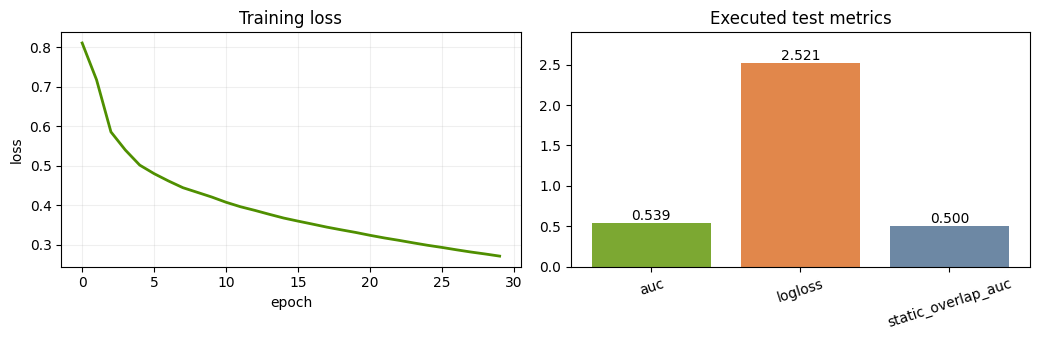

,value
auc,0.539245
logloss,2.521041
static_overlap_auc,0.500000


In [5]:
fig,axes=plt.subplots(1,2,figsize=(10.5,3.5))
axes[0].plot(result['loss_curve'],color='#4f8f00',lw=2); axes[0].set(title='Training loss',xlabel='epoch',ylabel='loss'); axes[0].grid(alpha=.2)
metrics={'auc': result['auc'], 'logloss': result['logloss'], 'static_overlap_auc': result['static_overlap_auc']}
axes[1].bar(range(len(metrics)),list(metrics.values()),color=['#7ca832','#e1874b','#6d88a4'][:len(metrics)])
axes[1].set_xticks(range(len(metrics)),list(metrics),rotation=18); axes[1].set(title='Executed test metrics',ylim=(0,max(1.0,max(metrics.values())*1.15)))
for index,value in enumerate(metrics.values()): axes[1].text(index,value,f'{value:.3f}',ha='center',va='bottom')
plt.tight_layout(); plt.show(); display(pd.Series(metrics,name='value').to_frame())

## Test & Results Discussion

In [6]:
display(Markdown(f'''### 本次已执行结果

- 主指标 auc = **{result['auc']:.4f}**。
- 辅助指标 logloss = **{result['logloss']:.4f}**。
- 对照指标 static_overlap_auc = **{result['static_overlap_auc']:.4f}**。
- 训练损失从 **{result['loss_curve'][0]:.4f}** 降到 **{result['loss_curve'][-1]:.4f}**。损失下降只说明优化工作，不等于泛化或业务收益。
- **结果解释：** 小数据下 DIEN 可能 AUC 尚可但 LogLoss 很差，应使用早停、校准和用户分桶，不能只看训练损失。

### 工业边界

严格按时间编码历史，候选控制 AUGRU 更新，最终状态进入 MLP；同时测 P99、吞吐和校准。

上线前还需验证延迟、吞吐、内存/显存、数据新鲜度、校准、回滚和线上 A/B。
'''))

### 本次已执行结果

- 主指标 auc = **0.5392**。
- 辅助指标 logloss = **2.5210**。
- 对照指标 static_overlap_auc = **0.5000**。
- 训练损失从 **0.8113** 降到 **0.2710**。损失下降只说明优化工作，不等于泛化或业务收益。
- **结果解释：** 小数据下 DIEN 可能 AUC 尚可但 LogLoss 很差，应使用早停、校准和用户分桶，不能只看训练损失。

### 工业边界

严格按时间编码历史，候选控制 AUGRU 更新，最终状态进入 MLP；同时测 P99、吞吐和校准。

上线前还需验证延迟、吞吐、内存/显存、数据新鲜度、校准、回滚和线上 A/B。


In [7]:
record={
    'algorithm': 'DIEN 兴趣演化排序',
    'primary_metric': 'auc', 'primary_value': float(result['auc']),
    'secondary_metric': 'logloss', 'secondary_value': float(result['logloss']),
    'baseline_metric': 'static_overlap_auc',
    'baseline_value': float(result['static_overlap_auc']) if True else None,
    'framework': result['framework'], 'source_notebook': '3_3_3_dien',
    'dataset': 'MovieLens latest-small',
    'randomly_fabricated_rows': int(result['dataset']['randomly_fabricated_rows'])
}
path=save_records('chapter_3_3','3_3_3_dien',[record]); print('saved:',path.relative_to(ROOT))

saved: results/chapter_3_3/3_3_3_dien.json


## Checks

自动断言用于防止数据、训练和指标链路静默失效，不是效果证明。

In [8]:
assert result['loss_curve'][-1] < result['loss_curve'][0]
assert 0 <= float(result['auc']) <= 1
assert np.isfinite(float(result['logloss']))
print('PASS：数据、训练、推理、测试和结果产物均已验证。')

PASS：数据、训练、推理、测试和结果产物均已验证。


## Next Steps

1. 换成对应公开数据的完整时间切分；2. 增加强 baseline 与消融；3. 记录效果、延迟和成本；4. 映射到 TorchEasyRec/官方 full profile；5. 只在相同候选与数据口径下比较。